# Human vs LLM — 分歧浏览

读 `output/{run_id}/comparison_wide.csv` 与 `eval_summary.csv`。

先跑（仓库根目录）：

```bash
python human_label_llm/experiment/20260529_object_v1_comment_only_test.py infer
python human_label_llm/experiment/20260529_object_v1_comment_only_test.py compare
```

下方改 `RUN_ID` 可切换实验。

In [8]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path("..").resolve()
REPO = ROOT.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
RUN_ID = "20260529_object_v1_comment_only_test"  # 与 experiment yaml 的 run_id 一致
OUT = ROOT / "output" / RUN_ID

summary = pd.read_csv(OUT / "eval_summary.csv")
wide = pd.read_csv(OUT / "comparison_wide.csv")
by_cat_path = OUT / "eval_by_category.csv"
if not by_cat_path.is_file():
    raise FileNotFoundError("请先运行: python human_label_llm/experiment/...py compare")
by_cat = pd.read_csv(by_cat_path)

row0 = summary.iloc[0]
MODEL_KEY = row0["model_key"]
SCOPE_ID = row0["scope_id"]
PRED_COL = row0["pred_column"]
GOLD_COL = row0["gold_column"]
REASON_COL = f"{PRED_COL}_reason"
STATUS_COL = f"{PRED_COL}_status"

# 与 compare 同口径的评估子集
ev = wide.copy()
if STATUS_COL in ev.columns:
    ev = ev[ev[STATUS_COL].astype(str) == "ok"]
ev = ev[
    ev[GOLD_COL].astype(str).str.strip().ne("")
    & ev[PRED_COL].astype(str).str.strip().ne("")
].copy()

print(f"rows={len(wide)}  eval={len(ev)}  output={OUT}")
summary

rows=312  eval=312  output=/Users/yilin/project/2604-robotic_failure_research/human_label_llm/output/20260529_object_v1_comment_only_test


,model_key,scope_id,gold_column,pred_column,n,accuracy,kappa,n_parse_error,n_api_error,n_agree,n_disagree,agreement_rate,disagreement_rate,macro_recall,macro_precision,macro_f1
0,deepseek_v4_pro,scope_comment_only,评估对象,llm_deepseek_v4_pro_scope_comment_only,311,0.6495,0.5163,0,0,202,109,0.6495,0.3505,0.5632,0.535,0.5358


In [2]:
disagree = ev[ev[GOLD_COL].astype(str) != ev[PRED_COL].astype(str)].copy()
cols = [
    "comment_id",
    "combo",
    GOLD_COL,
    PRED_COL,
    REASON_COL,
    "content",
    "帖子标题",
    "post_caption",
]
cols = [c for c in cols if c in disagree.columns]
acc = summary.iloc[0]["accuracy"]
kappa = summary.iloc[0]["kappa"]
print(f"{MODEL_KEY} / {SCOPE_ID}")
print(f"accuracy={acc}  kappa={kappa}")
print(f"disagreements: {len(disagree)} / {len(wide)} rows (eval n={summary.iloc[0]['n']})")
disagree[cols].head(20)

deepseek_v4_pro / scope_comment_only
accuracy=0.6495  kappa=0.5163
disagreements: 110 / 312 rows (eval n=311)


,comment_id,combo,评估对象,llm_deepseek_v4_pro_scope_comment_only,llm_deepseek_v4_pro_scope_comment_only_reason,content,帖子标题
2,69db5f2b0000000015007b88,观众+强势,其他人,自身经验,The comment expresses a personal subjective re...,还得给机器让道了,今晚的亦庄机器人马拉松测试\n\n
5,69dc9e48000000003502ac36,观众+强势,无主体,自身经验,The comment expresses the speaker's direct sen...,我看到了！,今晚的亦庄机器人马拉松测试\n\n
11,69dccd5c000000003502bf27,抢救者+失败,无主体,自身经验,The comment '我也是哈哈哈哈哈哈哈哈' translates to 'Me to...,我也是哈哈哈哈哈哈哈哈,机器人抢救现场\n\n
13,69e457ff000000001401e400,抢救者+失败,机器人本身,其他人,The comment likens dealing with robots to pedi...,可能类似儿科，碳基家长很难缠[笑哭R],机器人抢救现场\n\n
16,69dc73fa00000000350236af,抢救者+失败,事件,自身经验,The comment expresses a personal mistaken expe...,我还以为是机器人医生来救人[笑哭R],机器人抢救现场\n\n
18,69dca7eb0000000030027509,抢救者+失败,其他人,机器人本身,The comment directly addresses the robot's phy...,工程师学习一下给机器人心肺复苏,机器人抢救现场\n\n
21,69e0153c000000001400b357,观众+失败,事件,符号,The comment questions the meaning or purpose o...,意义在哪？,“扶我起来，我还能再跑10公里”
26,69e0eb750000000014018c1a,观众+失败,其他人,机器人本身,The comment evaluates the robot's state of bei...,在家里不做实验么拿出来现眼,“扶我起来，我还能再跑10公里”
28,69df99b9000000001500254a,观众+失败,符号,机器人本身,The comment directly evaluates the robots' exi...,现在就很好笑，再过几年他们中的很多都没有了[捂脸R],“扶我起来，我还能再跑10公里”
40,69e43c9b000000001401bc0d,服务者+常态,事件,符号,The comment questions the meaning of running a...,跑马拉松到底有什么意义。。,机器人马拉松现场第一视角看全部队伍\n\n


## 分类别指标

- **recall**：人工标为该类时，LLM 也标对的比例（常叫「该类准确率」）
- **precision / f1**：sklearn 分类报告
- **kappa_ovr**：该类 one-vs-rest 的 Cohen's κ（≠ 全局 κ）
- **全局 accuracy / kappa**：见上一格 `eval_summary.csv`

In [9]:
# 分类别 recall / precision / f1 / kappa_ovr（来自 compare 生成的 eval_by_category.csv）
show = by_cat.sort_values("n_gold", ascending=False)
cols_show = ["category", "n_gold", "n_correct", "recall", "precision", "f1", "kappa_ovr"]
show[cols_show].style.format(
    {"recall": "{:.1%}", "precision": "{:.1%}", "f1": "{:.1%}", "kappa_ovr": "{:.3f}"},
    na_rep="—",
)

print(
    f"全局: accuracy={row0['accuracy']:.4f}  kappa={row0['kappa']:.4f}  n={int(row0['n'])}"
)

全局: accuracy=0.6495  kappa=0.5163  n=311


## Gap 摘要（人–机一致 vs 分歧）

- **agreement / disagreement**：整体一致率 vs 分歧率（≠ 说谁对谁错，而是距离）
- **macro recall**：七类 recall 平均（比 overall accuracy 更反映类间 gap）
- **per-class gap**：每类 `miss_rate`、`gap_recall`（=1−recall）
- **Top 误判对**：人工→LLM 最常见的非对角组合

> 方法提醒：本实验 LLM 仅 `comment`；若人工标注时看过标题/正文，分歧里含 **输入 scope gap**。

=== 整体 Gap ===
一致 202/312 (64.7%)  |  分歧 110 (35.3%)
accuracy(micro)=0.6495  kappa=0.5163  |  macro_recall=0.5632  macro_f1=0.5358

=== 分类别 Gap（按 gap_recall 降序）===


,category,n_human,n_correct,n_miss,recall,miss_rate,gap_recall
0,事件,37,14,23,37.8%,62.2%,62.2%
1,其他,10,4,6,40.0%,60.0%,60.0%
2,其他人,27,11,16,40.7%,59.3%,59.3%
3,自身经验,15,9,6,60.0%,40.0%,40.0%
4,符号,32,22,10,68.8%,31.2%,31.2%
5,无主体,35,25,10,71.4%,28.6%,28.6%
6,机器人本身,155,117,38,75.5%,24.5%,24.5%



=== 每类最主要误判方向 ===


,category,n_miss,gap_recall,top_wrong_llm,top_n,top_pct
0,事件,23,0.6216,机器人本身,13,35.1
1,其他,6,0.6000,无主体,2,20.0
2,其他人,16,0.5926,机器人本身,6,22.2
3,自身经验,6,0.4000,符号,2,13.3
4,符号,10,0.3125,自身经验,5,15.6
5,无主体,10,0.2857,其他,4,11.4
6,机器人本身,38,0.2452,自身经验,14,9.0



=== Top 误判对（人工 → LLM）===


,model_key,scope_id,human,llm,n,pct_of_human
0,deepseek_v4_pro,scope_comment_only,机器人本身,自身经验,14,9.0
1,deepseek_v4_pro,scope_comment_only,事件,机器人本身,13,35.1
2,deepseek_v4_pro,scope_comment_only,机器人本身,其他人,7,4.5
3,deepseek_v4_pro,scope_comment_only,机器人本身,事件,7,4.5
4,deepseek_v4_pro,scope_comment_only,其他人,机器人本身,6,22.2
5,deepseek_v4_pro,scope_comment_only,符号,自身经验,5,15.6
6,deepseek_v4_pro,scope_comment_only,机器人本身,符号,5,3.2
7,deepseek_v4_pro,scope_comment_only,其他人,事件,4,14.8
8,deepseek_v4_pro,scope_comment_only,机器人本身,无主体,4,2.6
9,deepseek_v4_pro,scope_comment_only,其他人,自身经验,4,14.8


/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_81946/3859866419.py:60: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDEOGRAPH-4E8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_81946/3859866419.py:60: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_81946/3859866419.py:60: UserWarning: Glyph 20854 (\N{CJK UNIFIED IDEOGRAPH-5176}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_81946/3859866419.py:60: UserWarning: Glyph 20182 (\N{CJK UNIFIED IDEOGRAPH-4ED6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scpn22j73d8nv7rhtkq94jw0000gn/T/ipykernel_81946/3859866419.py:60: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s7/9scp

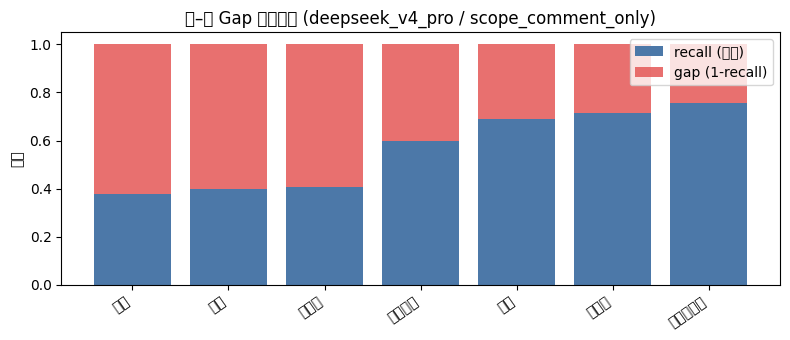

In [10]:
from human_label_llm.run import gap_misclassification_pairs, gap_summary_metrics, per_class_gap_table

try:
    from IPython.display import display
except ImportError:
    display = print

gap_pairs = pd.read_csv(OUT / "eval_gap_pairs.csv")
gap_class = pd.read_csv(OUT / "eval_gap_by_class.csv")

yt, yp = ev[GOLD_COL].astype(str).str.strip(), ev[PRED_COL].astype(str).str.strip()
gap = gap_summary_metrics(yt, yp, by_cat)

print("=== 整体 Gap ===")
print(
    f"一致 {gap['n_agree']}/{gap['n']} ({gap['agreement_rate']:.1%})  |  "
    f"分歧 {gap['n_disagree']} ({gap['disagreement_rate']:.1%})"
)
print(
    f"accuracy(micro)={row0['accuracy']:.4f}  kappa={row0['kappa']:.4f}  |  "
    f"macro_recall={gap['macro_recall']:.4f}  macro_f1={gap['macro_f1']:.4f}"
)

# 每类：人标了多少、漏判多少、gap=1-recall
gc = gap_class.sort_values("gap_recall", ascending=False, na_position="last")
print("\n=== 分类别 Gap（按 gap_recall 降序）===")
display(
    gc[["category", "n_human", "n_correct", "n_miss", "recall", "miss_rate", "gap_recall"]].style.format(
        {"recall": "{:.1%}", "miss_rate": "{:.1%}", "gap_recall": "{:.1%}"},
        na_rep="—",
    )
)

# 每类最主要误判去向（Top1 LLM 标签）
top1 = (
    gap_pairs.sort_values("n", ascending=False)
    .groupby("human", as_index=False)
    .first()[["human", "llm", "n", "pct_of_human"]]
    .rename(columns={"human": "category", "llm": "top_wrong_llm", "n": "top_n", "pct_of_human": "top_pct"})
)
gc_top = gc.merge(top1, on="category", how="left")
print("\n=== 每类最主要误判方向 ===")
display(gc_top[["category", "n_miss", "gap_recall", "top_wrong_llm", "top_n", "top_pct"]])

print("\n=== Top 误判对（人工 → LLM）===")
display(gap_pairs.head(15))

# 可选：画 macro recall vs gap
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 3.5))
    x = gc["category"]
    ax.bar(x, gc["recall"], label="recall (一致)", color="#4c78a8")
    ax.bar(x, gc["gap_recall"], bottom=gc["recall"], label="gap (1-recall)", color="#e45756", alpha=0.85)
    ax.set_ylabel("比例")
    ax.set_title(f"人–机 Gap 按类分解 ({MODEL_KEY} / {SCOPE_ID})")
    ax.legend(loc="upper right")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

## 分类别错例浏览（改下一格参数）

在 **`ev`** 上筛选，例如「人工=自身经验 且 LLM 标错」的所有行。

| 参数 | 说明 |
|------|------|
| `GOLD_LABEL` | 人工金标类别（`评估对象` 列） |
| `PRED_LABEL` | 可选：只看 LLM 错成哪一类；`None` 表示不限 |
| `MODE` | `wrong` 仅错例 / `correct` 仅对例 / `all_gold` 该类全部 |
| `DISPLAY_COLS` | 要显示的列（不存在会自动跳过） |
| `MAX_ROWS` | 最多显示行数 |

也可直接调 `browse_cases(...)`。

In [6]:
# ========= 改这里 =========
GOLD_LABEL = "事件"
PRED_LABEL = None          # 例: "机器人本身" — 只看错成机器人本身
MODE = "wrong"             # wrong | correct | all_gold
DISPLAY_COLS = [
    "comment_id",
    "combo",
    GOLD_COL,
    PRED_COL,
    REASON_COL,
    "content",
    "帖子标题",
    "post_caption",
]
MAX_ROWS = 50
# =========================


def browse_cases(
    gold_label: str,
    *,
    pred_label: str | None = None,
    mode: str = "wrong",
    cols: list[str] | None = None,
    n: int = 50,
) -> pd.DataFrame:
    """按人工类别筛选 ev；mode=wrong 为该类评错样本。"""
    g = ev[GOLD_COL].astype(str).str.strip()
    p = ev[PRED_COL].astype(str).str.strip()
    mask = g == gold_label
    if pred_label is not None:
        mask &= p == pred_label
    if mode == "wrong":
        mask &= g != p
    elif mode == "correct":
        mask &= g == p
    elif mode != "all_gold":
        raise ValueError("mode must be wrong | correct | all_gold")

    df = ev.loc[mask]
    use_cols = [c for c in (cols or DISPLAY_COLS) if c in df.columns]
    return df[use_cols].head(n)


# 该类指标（来自 by_cat）
m = by_cat[by_cat["category"].astype(str) == GOLD_LABEL]
if len(m):
    r = m.iloc[0]
    print(
        f"【{GOLD_LABEL}】n_gold={int(r['n_gold'])}  "
        f"recall={r['recall']:.1%}  precision={r['precision']:.1%}  "
        f"f1={r['f1']:.3f}  kappa_ovr={r['kappa_ovr']:.3f}"
    )
if PRED_LABEL:
    print(f"筛选: 人工={GOLD_LABEL}  LLM={PRED_LABEL}  mode={MODE}")
else:
    print(f"筛选: 人工={GOLD_LABEL}  mode={MODE}  共 {len(browse_cases(GOLD_LABEL, pred_label=PRED_LABEL, mode=MODE, n=10_000))} 行")

browse_cases(GOLD_LABEL, pred_label=PRED_LABEL, mode=MODE, cols=DISPLAY_COLS, n=MAX_ROWS)

【事件】n_gold=37  recall=37.8%  precision=51.8%  f1=0.438  kappa_ovr=0.375
筛选: 人工=事件  mode=wrong  共 23 行


,comment_id,combo,评估对象,llm_deepseek_v4_pro_scope_comment_only,llm_deepseek_v4_pro_scope_comment_only_reason,content,帖子标题
16,69dc73fa00000000350236af,抢救者+失败,事件,自身经验,The comment expresses a personal mistaken expe...,我还以为是机器人医生来救人[笑哭R],机器人抢救现场\n\n
21,69e0153c000000001400b357,观众+失败,事件,符号,The comment questions the meaning or purpose o...,意义在哪？,“扶我起来，我还能再跑10公里”
40,69e43c9b000000001401bc0d,服务者+常态,事件,符号,The comment questions the meaning of running a...,跑马拉松到底有什么意义。。,机器人马拉松现场第一视角看全部队伍\n\n
42,69e43b42000000001401d83a,服务者+常态,事件,机器人本身,The comment '这难道不很有趣吗？' ('Isn't this interesti...,这难道不很有趣吗？,机器人马拉松现场第一视角看全部队伍\n\n
43,69e43bb8000000001401e81f,服务者+常态,事件,机器人本身,The comment directly describes the robot's ope...,特斯拉一样是遥控还有vr操作的,机器人马拉松现场第一视角看全部队伍\n\n
77,69e5a63f0000000014018802,观众+弱势,事件,其他人,The comment asks about the whereabouts of 'GG'...,GG呢？,机器人马拉松倒数第一名，萌翻了���\n\n
88,69e45d32000000001401e826,观众+常态,事件,机器人本身,评论直接评价了机器人本体的来源（宇树），核心是机器人的实体身份，而非事件、个人体验或象征意义。,机器人本体是宇树的，但是参加的公司不是,机器人嘲讽同伴\n\n
110,69e4612a000000001401d43b,观众+混合,事件,机器人本身,The comment mocks the harsh judgment of a robo...,哈哈哈哈笑死，连机器人都不放过！明年应该颜值会高起来～,机器人马拉松比赛摔倒丝滑起身帅炸了��\n\n
155,69e45c350000000014019419,观众+常态,事件,其他,The comment is a generic thank-you message and...,感谢关注[派对R]小派亲友团发来贺电,论机器人上班的精神状态…\n\n
173,69e56a080000000014018811,观众+强势,事件,其他人,评论询问'华子'在哪里，'华子'是人的昵称，关注点在第三方人类而非机器人本身,华子何在,机器人跑马拉松超越人类？\n\n


## 列联表

- **行 = 人工金标**（`评估对象`），**列 = LLM 预测**
- **对角线** = 判对；**非对角** = 误判方向（行类别被错判到哪一列）
- **行合计 All** = 该类人工标注条数；**列合计** = LLM 预测为该类次数

下面三张表：
1. **人数**
2. **行内比例 %**（固定人工类别：LLM 各类占比，每行和=100%）← 最常看
3. **列内比例 %**（固定 LLM 预测：来自哪类人工，每列和=100%）

In [7]:
# 列联表（ev 已在第 1 格建好）
try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

ct = pd.crosstab(ev[GOLD_COL], ev[PRED_COL], margins=True)
labels = [x for x in ct.index if x != "All"]
cols_only = [x for x in ct.columns if x != "All"]

# 1) 人数
print("=== 人数（行=人工，列=LLM）===")
display(ct)

# 2) 行内 % ：人工=某类时，LLM 判为各类的比例（对角线=该类 recall）
ct_row = ct.loc[labels, cols_only].astype(float)
ct_row_pct = ct_row.div(ct_row.sum(axis=1), axis=0).mul(100).round(1)
ct_row_pct["行合计"] = ct.loc[labels, "All"].values
print("\n=== 行内比例 %（每行和=100%，对角线越高越好）===")
display(ct_row_pct.style.format("{:.1f}", na_rep="—").background_gradient(
    cmap="Blues", axis=1, subset=pd.IndexSlice[labels, cols_only]
))

# 对角线 recall 标注
print("\n各类 recall（对角线 / 行合计）:")
for lab in labels:
    n = ct.loc[lab, "All"]
    hit = ct.loc[lab, lab] if lab in cols_only else 0
    print(f"  {lab}: {hit}/{n} = {hit/n:.1%}" if n else f"  {lab}: —")

# 3) 列内 % ：LLM 判为某类时，来自哪类人工
ct_col = ct.loc[labels, cols_only].astype(float)
ct_col_pct = ct_col.div(ct_col.sum(axis=0), axis=1).mul(100).round(1)
ct_col_pct.loc["列合计"] = ct.loc["All", cols_only].values
print("\n=== 列内比例 %（每列和=100%）===")
display(ct_col_pct)

=== 人数（行=人工，列=LLM）===


llm_deepseek_v4_pro_scope_comment_only,事件,其他,其他人,无主体,机器人本身,符号,自身经验,All
评估对象,,,,,,,,
事件,14,2,2,0,13,3,3,37
其他,1,4,1,2,1,1,0,10
其他人,4,0,11,1,6,1,4,27
无主体,0,4,2,25,1,1,2,35
机器人本身,7,1,7,4,117,5,14,155
符号,1,1,1,0,2,22,5,32
自身经验,0,0,1,1,2,2,9,15
All,27,12,25,33,142,35,37,311



=== 行内比例 %（每行和=100%，对角线越高越好）===


llm_deepseek_v4_pro_scope_comment_only,事件,其他,其他人,无主体,机器人本身,符号,自身经验,行合计
评估对象,,,,,,,,
事件,37.8,5.4,5.4,0.0,35.1,8.1,8.1,37.0
其他,10.0,40.0,10.0,20.0,10.0,10.0,0.0,10.0
其他人,14.8,0.0,40.7,3.7,22.2,3.7,14.8,27.0
无主体,0.0,11.4,5.7,71.4,2.9,2.9,5.7,35.0
机器人本身,4.5,0.6,4.5,2.6,75.5,3.2,9.0,155.0
符号,3.1,3.1,3.1,0.0,6.2,68.8,15.6,32.0
自身经验,0.0,0.0,6.7,6.7,13.3,13.3,60.0,15.0



各类 recall（对角线 / 行合计）:
  事件: 14/37 = 37.8%
  其他: 4/10 = 40.0%
  其他人: 11/27 = 40.7%
  无主体: 25/35 = 71.4%
  机器人本身: 117/155 = 75.5%
  符号: 22/32 = 68.8%
  自身经验: 9/15 = 60.0%

=== 列内比例 %（每列和=100%）===


llm_deepseek_v4_pro_scope_comment_only,事件,其他,其他人,无主体,机器人本身,符号,自身经验
评估对象,,,,,,,
事件,51.9,16.7,8.0,0.0,9.2,8.6,8.1
其他,3.7,33.3,4.0,6.1,0.7,2.9,0.0
其他人,14.8,0.0,44.0,3.0,4.2,2.9,10.8
无主体,0.0,33.3,8.0,75.8,0.7,2.9,5.4
机器人本身,25.9,8.3,28.0,12.1,82.4,14.3,37.8
符号,3.7,8.3,4.0,0.0,1.4,62.9,13.5
自身经验,0.0,0.0,4.0,3.0,1.4,5.7,24.3
列合计,27.0,12.0,25.0,33.0,142.0,35.0,37.0
